# FDA 이상사례 데이터 - ATC M코드, C군(디클로페낙 국소겔) 인사이트 분석

전체 FDA 이상사례 보고 데이터 중 ATC 1단계 코드 M(Musculo-skeletal system, 근골격계) 의약품을
suspect_drug 종류별로 이부프로펜 단일제(A) / 나프록센 단일제(B) / 디클로페낙 단일제(C) / 국소 소염진통제(D, 외용)
로 재분류했을 때, 이 중 C군(디클로페낙 단일제, 도출_ATC코드 == "M02AA15", 성분 Diclofenac sodium topical gel 1%)
에 대해서만 아래 항목을 분석합니다.

1. C군 정의 확인 (건수 검증)
2. 인체 특성 (연령.성별)
3. 심각도 (사망.입원.생명위협.장애.회복여부)
4. 병용 약물 수 (다제복용)
5. 투약 사유(적응증)
6. 이상반응 유형
7. 전체 반응(reactions) 분해 및 동시발생 히트맵
8. 임신 중 노출 및 태아 영향 심층 분석
9. NSAID 도메인 지식 연계 심층 분석 (Nicolau 증후군·심혈관/신장 신호)
10. 참조표(FDA 라벨) 안전정보 대비 실제 신고 성향
11. 심각도(serious)와 인체특성·병용약물의 관계
12. 숫자형 변수 상관관계 히트맵
13. 같은 ATC코드(M) 내 비교 - 국소 겔 vs 경구 NSAID
14. 종합 인사이트 요약

비교 기준선은 C군을 제외한 전체 데이터(나머지 전체, Rest)로 설정합니다.

(※ 시계열/브랜드·제조사 기반 분석은 제외했습니다 - quarter는 FDA 보고서 "접수일" 기준이라 실제 발생 시점을
반영하지 못하고, 브랜드·제조사별 보고 건수/비율도 실사용량 등 노출 분모가 없어 위험도 비교로 쓰기 어렵기 때문입니다.)

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
!apt-get -qq install fonts-nanum > /dev/null
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams["figure.dpi"] = 110

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

In [2]:
# 색상 팔레트 (범주형 고정 순서 + 상태색)
C1_BLUE, C2_AQUA, C3_YELLOW, C4_GREEN = "#2a78d6", "#1baf7a", "#eda100", "#008300"
C5_VIOLET, C6_RED, C7_MAGENTA, C8_ORANGE = "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"
MUTED, GRID, INK, INK2 = "#898781", "#e1e0d9", "#0b0b0b", "#52514e"
STATUS_CRIT = "#d03b3b"

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(colors=INK2, labelsize=9)
    ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    if title:
        ax.set_title(title, fontsize=12, color=INK, fontweight="bold", pad=10)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=9.5, color=INK2)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=9.5, color=INK2)

def p_str(x):
    return "p < 0.001" if x < 0.001 else "p = {:.3f}".format(x)

## 데이터 로드 및 C군(디클로페낙 국소겔) 정의

In [3]:
DATA_PATH = "FDA_adverse_events_final_참조표병합.csv"  # 노트북과 같은 폴더에 위치

df = pd.read_csv(DATA_PATH, low_memory=False)
df["age_num"] = pd.to_numeric(df["patient_age_years"], errors="coerce")
df["weight_num"] = pd.to_numeric(df["patient_weight_kg"], errors="coerce")

# 코드 M(근골격계) 전체 및 세부 그룹
m_all = df[df["도출_ATC코드"].astype(str).str.startswith("M")].copy()
print("코드 M(근골격계) 전체 건수:", f"{len(m_all):,}")
print(m_all["도출_ATC코드"].value_counts())
print()

# C군 = 디클로페낙 국소겔(Diclofenac sodium topical gel 1%), ATC 도출코드 M02AA15
is_C = df["도출_ATC코드"] == "M02AA15"
c = df[is_C].copy()
rest = df[~is_C].copy()

print(f"C군(디클로페낙 국소겔) 건수: {len(c):,}  (참고: 제공 이미지 기준 260건, 13.2% - 정확히 일치)")
print(f"C군 비중(코드 M 내): {len(c)/len(m_all)*100:.1f}%")
print(f"C군 대표 성분: {c['참조_영문성분명'].unique()}")
print(f"나머지 전체(Rest) 건수: {len(rest):,}")
print()
c_serious_pct = (c['serious']=='Yes').mean()*100
rest_serious_pct = (rest['serious']=='Yes').mean()*100
print(f"C군 심각(serious) 비율: {c_serious_pct:.1f}%  (이미지 기준 82.7% - 일치)")
print(f"C군 사망(fatal) 비율: {c['is_fatal'].mean()*100:.1f}%  (이미지 기준 8.8% - 일치)")
print(f"참고: 나머지 전체(Rest)의 심각 비율은 {rest_serious_pct:.1f}%로, 이 데이터셋 자체가 대부분 '심각' 보고 위주로 구성되어 있어")
print("      단순 '심각 비율이 높다/낮다'만으로 비교하기보다, 사망/입원/생명위협/장애 등 세부 지표별 비교가 더 의미 있음(3번 섹션 참고)")

코드 M(근골격계) 전체 건수: 2,170
도출_ATC코드
M01AE01    1517
M01AE02     393
M02AA15     260
Name: count, dtype: int64

C군(디클로페낙 국소겔) 건수: 260  (참고: 제공 이미지 기준 260건, 13.2% - 정확히 일치)
C군 비중(코드 M 내): 12.0%
C군 대표 성분: ['Diclofenac sodium topical gel 1%']
나머지 전체(Rest) 건수: 18,013

C군 심각(serious) 비율: 82.7%  (이미지 기준 82.7% - 일치)
C군 사망(fatal) 비율: 8.8%  (이미지 기준 8.8% - 일치)
참고: 나머지 전체(Rest)의 심각 비율은 85.6%로, 이 데이터셋 자체가 대부분 '심각' 보고 위주로 구성되어 있어
      단순 '심각 비율이 높다/낮다'만으로 비교하기보다, 사망/입원/생명위협/장애 등 세부 지표별 비교가 더 의미 있음(3번 섹션 참고)


## 2. 인체 특성 (연령 · 성별)

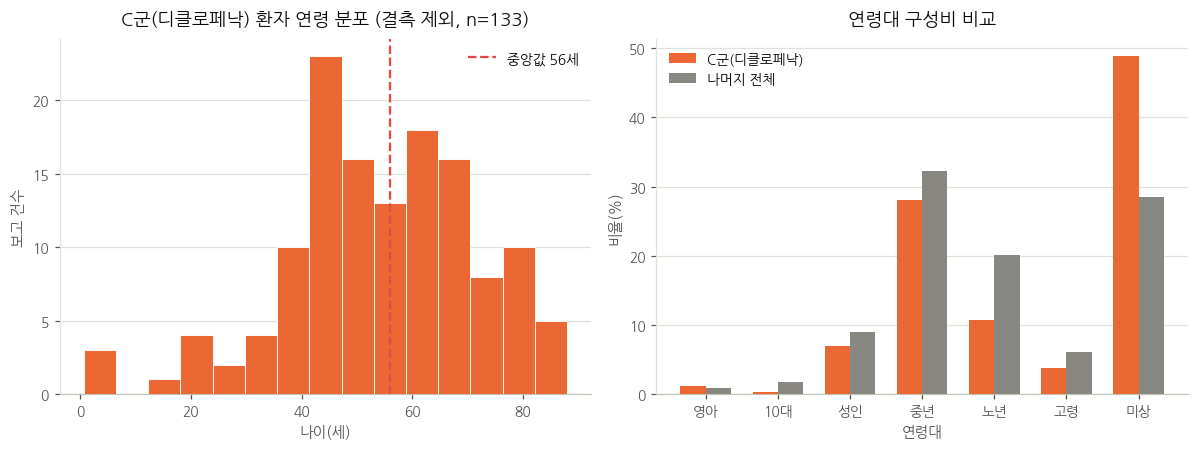

[연령] Mann-Whitney U 검정: U=765252, p = 0.033  (C군 중앙값 56세 vs Rest 중앙값 60세 - C군이 유의하게 젊음)
[연령 결측] C군 48.8% vs Rest 28.5% - C군의 연령 미상 비율이 더 높음


In [4]:
age_c = c["age_num"].dropna()
age_rest = rest["age_num"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(age_c, bins=15, color=C8_ORANGE, edgecolor="white", linewidth=0.6, zorder=3)
axes[0].axvline(age_c.median(), color=C6_RED, linestyle="--", linewidth=1.5, zorder=4,
                label=f"중앙값 {age_c.median():.0f}세")
style_ax(axes[0], f"C군(디클로페낙) 환자 연령 분포 (결측 제외, n={len(age_c):,})", "나이(세)", "보고 건수")
axes[0].legend(frameon=False, fontsize=9)

ag_order = ["Infant(0-2)", "Teen(13-18)", "Adult(19-40)", "Middle-Aged(41-65)", "Senior(66-80)", "Elderly(81+)", "Unknown"]
ag_labels = ["영아", "10대", "성인", "중년", "노년", "고령", "미상"]
c_ag_pct = c["age_group"].value_counts(normalize=True).reindex(ag_order).fillna(0) * 100
rest_ag_pct = rest["age_group"].value_counts(normalize=True).reindex(ag_order).fillna(0) * 100
x = np.arange(len(ag_order)); w = 0.35
axes[1].bar(x - w/2, c_ag_pct.values, w, label="C군(디클로페낙)", color=C8_ORANGE, zorder=3)
axes[1].bar(x + w/2, rest_ag_pct.values, w, label="나머지 전체", color=MUTED, zorder=3)
axes[1].set_xticks(x); axes[1].set_xticklabels(ag_labels, fontsize=8.5)
style_ax(axes[1], "연령대 구성비 비교", "연령대", "비율(%)")
axes[1].legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

u_age, p_age = stats.mannwhitneyu(age_c, age_rest, alternative="two-sided")
print(f"[연령] Mann-Whitney U 검정: U={u_age:.0f}, {p_str(p_age)}  (C군 중앙값 {age_c.median():.0f}세 vs Rest 중앙값 {age_rest.median():.0f}세 - C군이 유의하게 젊음)")
print(f"[연령 결측] C군 {(c['age_group']=='Unknown').mean()*100:.1f}% vs Rest {(rest['age_group']=='Unknown').mean()*100:.1f}% - C군의 연령 미상 비율이 더 높음")

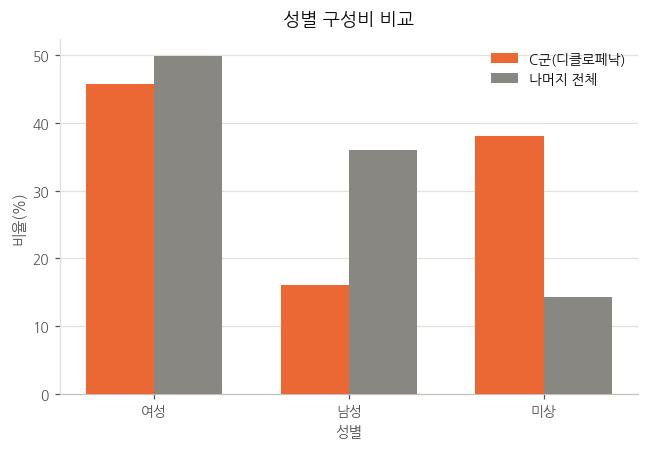

patient_sex
Female     119
Unknown     99
Male        42
Name: count, dtype: int64

[성별 미상 비율] C군 38.1% vs Rest 14.3% - C군에서 성별 미상 보고가 뚜렷이 많음(보고서 기재 부실 가능성)
[체중] 결측 아닌 값: 31/260건(11.9%) - 역시 대부분 결측, 참고용으로만 사용


In [5]:
sex_order = ["Female", "Male", "Unknown"]
sex_labels = ["여성", "남성", "미상"]
c_sex_pct = c["patient_sex"].value_counts(normalize=True).reindex(sex_order).fillna(0) * 100
rest_sex_pct = rest["patient_sex"].value_counts(normalize=True).reindex(sex_order).fillna(0) * 100

fig, ax = plt.subplots(figsize=(6, 4.2))
x = np.arange(len(sex_order)); w = 0.35
ax.bar(x - w/2, c_sex_pct.values, w, label="C군(디클로페낙)", color=C8_ORANGE, zorder=3)
ax.bar(x + w/2, rest_sex_pct.values, w, label="나머지 전체", color=MUTED, zorder=3)
ax.set_xticks(x); ax.set_xticklabels(sex_labels)
style_ax(ax, "성별 구성비 비교", "성별", "비율(%)")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

print(c["patient_sex"].value_counts())
c_unknown_sex = (c['patient_sex']=='Unknown').mean()*100
rest_unknown_sex = (rest['patient_sex']=='Unknown').mean()*100
print(f"\n[성별 미상 비율] C군 {c_unknown_sex:.1f}% vs Rest {rest_unknown_sex:.1f}% - C군에서 성별 미상 보고가 뚜렷이 많음(보고서 기재 부실 가능성)")

w_c = c['weight_num'].dropna()
print(f"[체중] 결측 아닌 값: {len(w_c)}/{len(c)}건({len(w_c)/len(c)*100:.1f}%) - 역시 대부분 결측, 참고용으로만 사용")

## 3. 심각도 (사망·입원·생명위협·장애·회복여부)

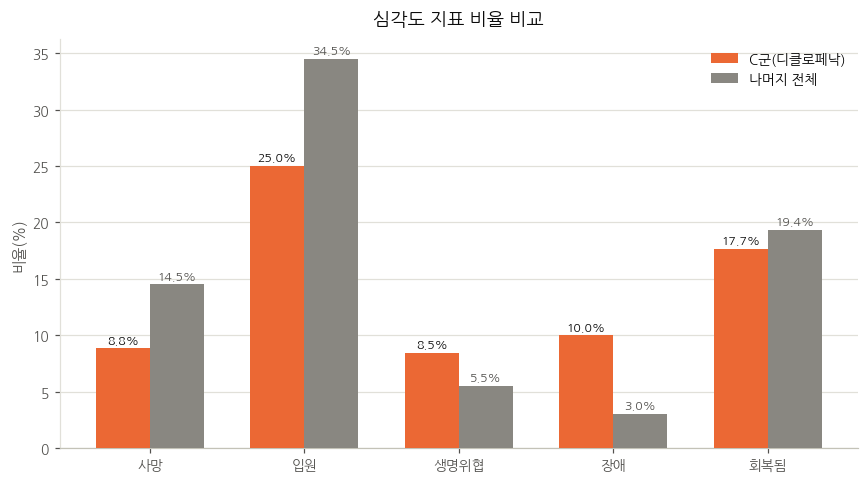

[C군 vs Rest] Chi-square 독립성 검정 (각 심각도 지표):
  - 사망    : C군   8.8% vs Rest  14.5%  |  chi2=   6.2, p = 0.013
  - 입원    : C군  25.0% vs Rest  34.5%  |  chi2=   9.9, p = 0.002
  - 생명위협  : C군   8.5% vs Rest   5.5%  |  chi2=   3.8, p = 0.052
  - 장애    : C군  10.0% vs Rest   3.0%  |  chi2=  38.5, p < 0.001
  - 회복됨   : C군  17.7% vs Rest  19.4%  |  chi2=   0.4, p = 0.552

[해석] 사망·입원 비율은 Rest보다 낮지만, 생명위협·장애 비율은 Rest보다 뚜렷이 높음(장애는 약 3.3배) -
      단순 사망률이 아니라 '비가역적 손상' 축에서 위험이 두드러지는 독특한 심각도 패턴

[C군 내부] serious_flags 세부 내역 (상위 10개):
serious_flags
Unknown                                                                     174
Hospitalization                                                              37
Death                                                                         9
Hospitalization; Disability                                                   8
Hospitalization; Life-Threatening                                             5
Disability                                                     

In [6]:
sev_cols = ["is_fatal", "is_hospitalized", "is_life_threat", "is_disabling", "patient_recovered"]
sev_labels = ["사망", "입원", "생명위협", "장애", "회복됨"]

c_rate = [c[col].mean() * 100 for col in sev_cols]
rest_rate = [rest[col].mean() * 100 for col in sev_cols]

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(sev_cols)); w = 0.35
ax.bar(x - w/2, c_rate, w, label="C군(디클로페낙)", color=C8_ORANGE, zorder=3)
ax.bar(x + w/2, rest_rate, w, label="나머지 전체", color=MUTED, zorder=3)
ax.set_xticks(x); ax.set_xticklabels(sev_labels)
style_ax(ax, "심각도 지표 비율 비교", None, "비율(%)")
ax.legend(frameon=False, fontsize=9)
for xi, (cv, rv) in enumerate(zip(c_rate, rest_rate)):
    ax.text(xi - w/2, cv + 0.5, f"{cv:.1f}%", ha="center", fontsize=8, color=INK)
    ax.text(xi + w/2, rv + 0.5, f"{rv:.1f}%", ha="center", fontsize=8, color=INK2)
plt.tight_layout()
plt.show()

print("[C군 vs Rest] Chi-square 독립성 검정 (각 심각도 지표):")
for col, lab in zip(sev_cols, sev_labels):
    ct = pd.crosstab(df["도출_ATC코드"].eq("M02AA15"), df[col])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    print(f"  - {lab:6s}: C군 {c[col].mean()*100:5.1f}% vs Rest {rest[col].mean()*100:5.1f}%  |  chi2={chi2:6.1f}, {p_str(p)}")

print("\n[해석] 사망·입원 비율은 Rest보다 낮지만, 생명위협·장애 비율은 Rest보다 뚜렷이 높음(장애는 약 3.3배) -")
print("      단순 사망률이 아니라 '비가역적 손상' 축에서 위험이 두드러지는 독특한 심각도 패턴")

print("\n[C군 내부] serious_flags 세부 내역 (상위 10개):")
print(c["serious_flags"].value_counts().head(10))

## 4. 병용 약물 수 (다제복용)

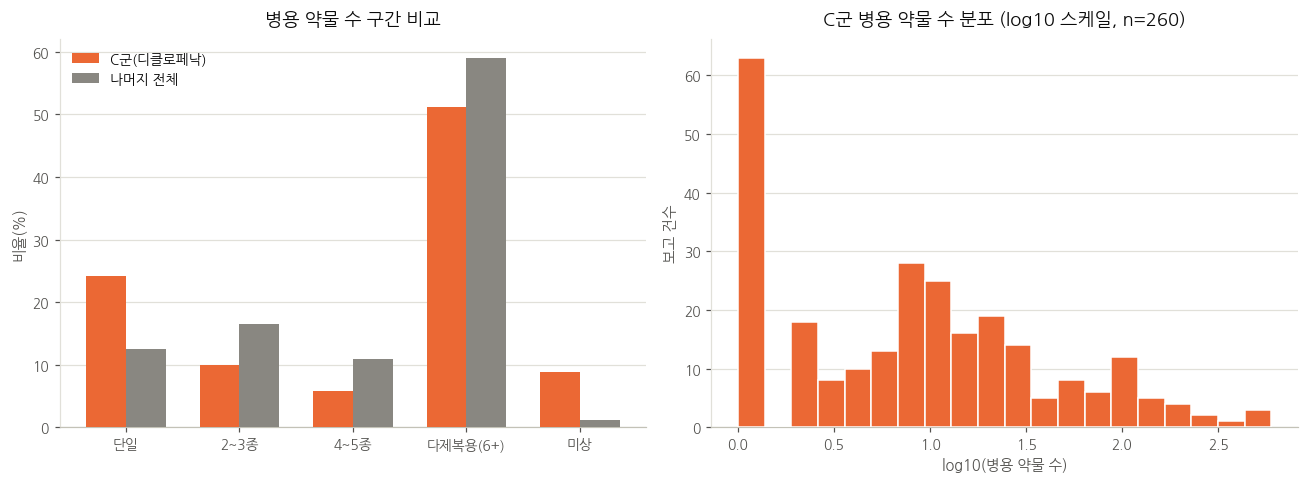

[병용 약물 수] Mann-Whitney U 검정: U=2245454, p = 0.254  (중앙값 기준 유의한 차이 없음)
  C군 중앙값 8종 (평균 31.16, 최댓값 599) vs Rest 중앙값 9종 (평균 17.60, 최댓값 2108)
→ 중앙값은 Rest와 비슷하지만 평균은 C군이 훨씬 높음(31.2 vs 17.6) - 극단적 다제복용 사례(최대 599종) 소수가 평균을 끌어올림
drug_count_category
Polypharmacy(6+)    133
Single               63
2-3 Drugs            26
Unknown              23
4-5 Drugs            15
Name: count, dtype: int64


In [7]:
cat_order = ["Single", "2-3 Drugs", "4-5 Drugs", "Polypharmacy(6+)", "Unknown"]
cat_labels = ["단일", "2~3종", "4~5종", "다제복용(6+)", "미상"]
c_cat_pct = c["drug_count_category"].value_counts(normalize=True).reindex(cat_order).fillna(0) * 100
rest_cat_pct = rest["drug_count_category"].value_counts(normalize=True).reindex(cat_order).fillna(0) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(len(cat_order)); w = 0.35
axes[0].bar(x - w/2, c_cat_pct.values, w, label="C군(디클로페낙)", color=C8_ORANGE, zorder=3)
axes[0].bar(x + w/2, rest_cat_pct.values, w, label="나머지 전체", color=MUTED, zorder=3)
axes[0].set_xticks(x); axes[0].set_xticklabels(cat_labels, fontsize=8.5)
style_ax(axes[0], "병용 약물 수 구간 비교", None, "비율(%)")
axes[0].legend(frameon=False, fontsize=9)

# 최댓값 599 등 극단치가 있어 로그 스케일로 분포 시각화
axes[1].hist(np.log10(c["num_drugs"]), bins=20, color=C8_ORANGE, edgecolor="white", zorder=3)
style_ax(axes[1], f"C군 병용 약물 수 분포 (log10 스케일, n={len(c):,})", "log10(병용 약물 수)", "보고 건수")
plt.tight_layout()
plt.show()

u_nd, p_nd = stats.mannwhitneyu(c["num_drugs"], rest["num_drugs"], alternative="two-sided")
print(f"[병용 약물 수] Mann-Whitney U 검정: U={u_nd:.0f}, {p_str(p_nd)}  (중앙값 기준 유의한 차이 없음)")
print(f"  C군 중앙값 {c['num_drugs'].median():.0f}종 (평균 {c['num_drugs'].mean():.2f}, 최댓값 {c['num_drugs'].max():.0f}) vs "
      f"Rest 중앙값 {rest['num_drugs'].median():.0f}종 (평균 {rest['num_drugs'].mean():.2f}, 최댓값 {rest['num_drugs'].max():.0f})")
print("→ 중앙값은 Rest와 비슷하지만 평균은 C군이 훨씬 높음(31.2 vs 17.6) - 극단적 다제복용 사례(최대 599종) 소수가 평균을 끌어올림")
print(c["drug_count_category"].value_counts())

## 5. 투약 사유 (적응증, drug_indication)

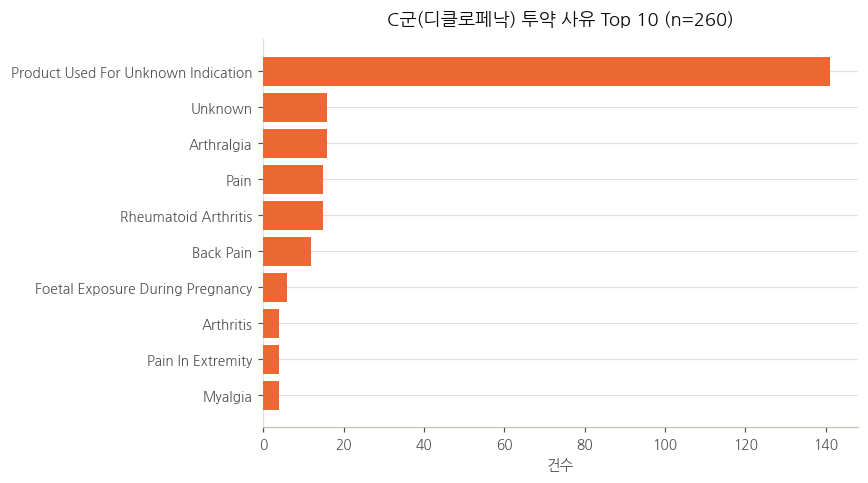

drug_indication
Product Used For Unknown Indication    141
Unknown                                 16
Arthralgia                              16
Pain                                    15
Rheumatoid Arthritis                    15
Back Pain                               12
Foetal Exposure During Pregnancy         6
Arthritis                                4
Pain In Extremity                        4
Myalgia                                  4
Name: count, dtype: int64

'Product Used For Unknown Indication'(적응증 미기재) 비율: 54.2% - 관절염 등 만성 통증 자가치료 특성상 매우 높음
'임신 중 노출'(Foetal Exposure During Pregnancy) 적응증 기재: 6건 - 8번 섹션에서 심층 분석


In [8]:
top_ind = c["drug_indication"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(top_ind.index[::-1], top_ind.values[::-1], color=C8_ORANGE, zorder=3)
style_ax(ax, f"C군(디클로페낙) 투약 사유 Top 10 (n={len(c):,})", "건수", None)
plt.tight_layout()
plt.show()

print(top_ind)
unapproved_pct = (c['drug_indication']=='Product Used For Unknown Indication').mean()*100
print(f"\n'Product Used For Unknown Indication'(적응증 미기재) 비율: {unapproved_pct:.1f}% - 관절염 등 만성 통증 자가치료 특성상 매우 높음")
preg_ind = c['drug_indication'].str.contains('Foetal|Pregnan', case=False, na=False).sum()
print(f"'임신 중 노출'(Foetal Exposure During Pregnancy) 적응증 기재: {preg_ind}건 - 8번 섹션에서 심층 분석")

## 6. 이상반응 유형 (primary_reaction)

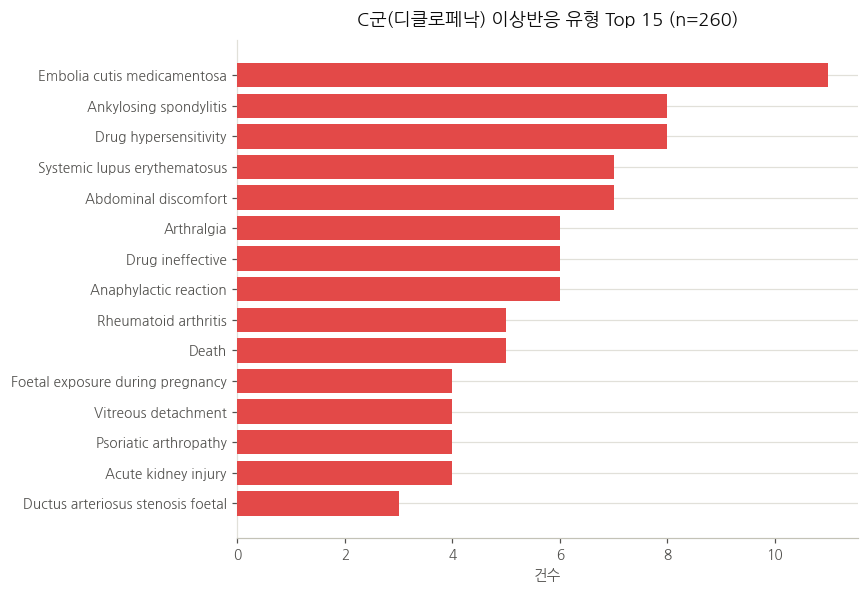

primary_reaction
Embolia cutis medicamentosa          11
Ankylosing spondylitis                8
Drug hypersensitivity                 8
Systemic lupus erythematosus          7
Abdominal discomfort                  7
Arthralgia                            6
Drug ineffective                      6
Anaphylactic reaction                 6
Rheumatoid arthritis                  5
Death                                 5
Foetal exposure during pregnancy      4
Vitreous detachment                   4
Psoriatic arthropathy                 4
Acute kidney injury                   4
Ductus arteriosus stenosis foetal     3
Name: count, dtype: int64

[특이 신호] 'Systemic lupus erythematosus'(전신 홍반성 루푸스)가 대표 반응으로 7건 -
  NSAID 계열에서 드물게 보고되는 '약물유발 루푸스(drug-induced lupus)' 가능성을 시사하는 패턴

[알레르기/과민반응 계열 비율] C군 8.5% vs Rest 2.3%


In [9]:
top_rx = c["primary_reaction"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top_rx.index[::-1], top_rx.values[::-1], color=C6_RED, zorder=3)
style_ax(ax, f"C군(디클로페낙) 이상반응 유형 Top 15 (n={len(c):,})", "건수", None)
plt.tight_layout()
plt.show()

print(top_rx)

sle_n = (c['primary_reaction']=='Systemic lupus erythematosus').sum()
print(f"\n[특이 신호] 'Systemic lupus erythematosus'(전신 홍반성 루푸스)가 대표 반응으로 {sle_n}건 -")
print("  NSAID 계열에서 드물게 보고되는 '약물유발 루푸스(drug-induced lupus)' 가능성을 시사하는 패턴")

allergy_kw = ['hypersensitivity', 'anaphylactic', 'allergic', 'angioedema']
is_allergy_c = c['primary_reaction'].str.lower().str.contains('|'.join(allergy_kw), na=False)
is_allergy_rest = rest['primary_reaction'].str.lower().str.contains('|'.join(allergy_kw), na=False)
print(f"\n[알레르기/과민반응 계열 비율] C군 {is_allergy_c.mean()*100:.1f}% vs Rest {is_allergy_rest.mean()*100:.1f}%")

## 7. 전체 반응(reactions) 분해 및 동시발생 히트맵

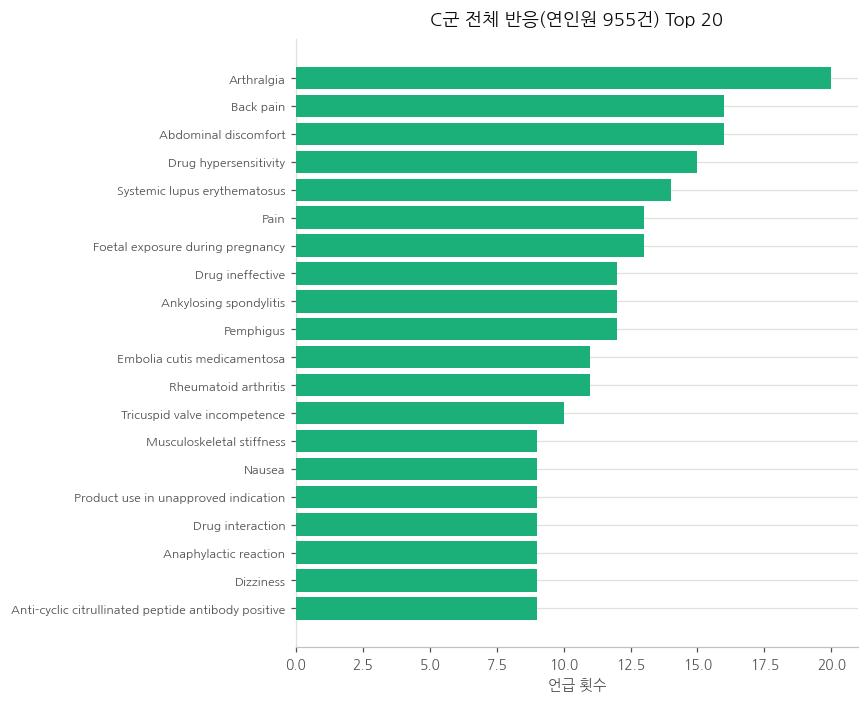

보고서 260건에서 총 955건의 개별 반응이 언급됨 (건당 평균 3.67개 - 나머지 전체보다 훨씬 많음)


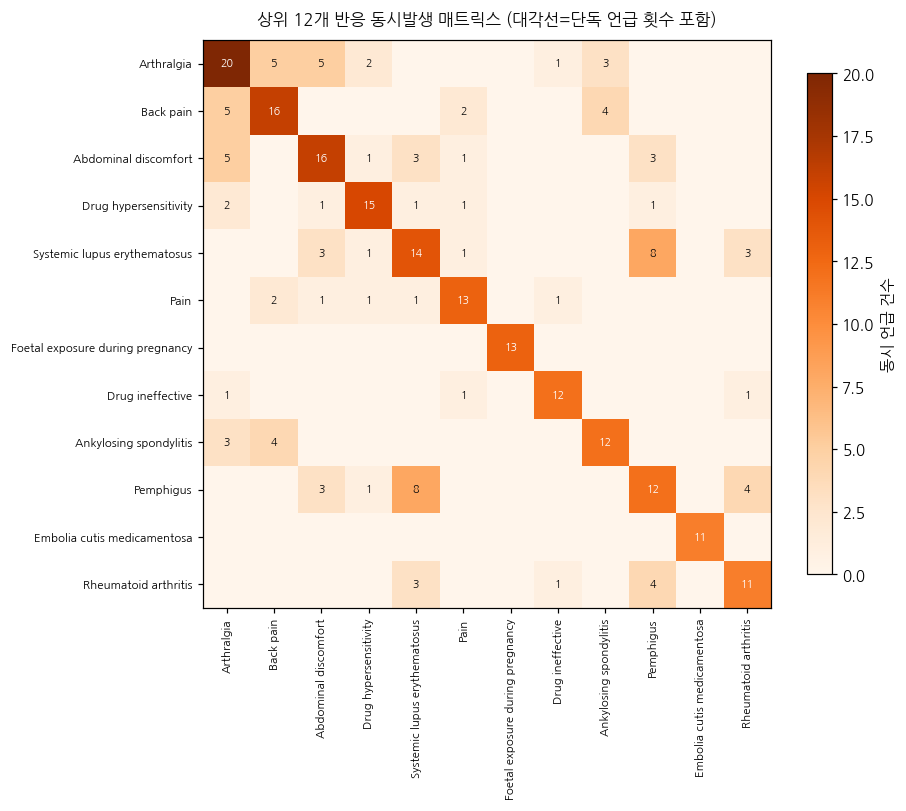

[해석] 관절통(Arthralgia)·요통(Back pain)·복부불편감(Abdominal discomfort)이 여러 관절/자가면역 관련
      반응(강직성 척추염, 류마티스 관절염, 루푸스 등)과 함께 자주 동반 언급됨 -
      이는 C군 신고의 상당수가 '약효 부족/원질환 악화' 맥락에서 다발성 증상으로 보고됨을 시사


In [10]:
from collections import Counter
from itertools import combinations

react_lists = c["reactions"].fillna("").apply(lambda s: [x.strip() for x in s.split(";") if x.strip()])
all_react = [r for lst in react_lists for r in lst]
react_counter = Counter(all_react)
top20 = react_counter.most_common(20)

fig, ax = plt.subplots(figsize=(8, 6.5))
labels = [t[0] for t in top20][::-1]
values = [t[1] for t in top20][::-1]
ax.barh(labels, values, color=C2_AQUA, zorder=3)
style_ax(ax, f"C군 전체 반응(연인원 {len(all_react)}건) Top 20", "언급 횟수", None)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

print(f"보고서 {len(c)}건에서 총 {len(all_react)}건의 개별 반응이 언급됨 (건당 평균 {len(all_react)/len(c):.2f}개 - 나머지 전체보다 훨씬 많음)")

top12 = [r for r, cnt in react_counter.most_common(12)]
cooc = pd.DataFrame(0, index=top12, columns=top12)
for lst in react_lists:
    present = [r for r in top12 if r in lst]
    for a, b in combinations(present, 2):
        cooc.loc[a, b] += 1
        cooc.loc[b, a] += 1
    for a in present:
        cooc.loc[a, a] += 1

fig, ax = plt.subplots(figsize=(8.5, 7.5))
im = ax.imshow(cooc.values, cmap="Oranges", vmin=0)
ax.set_xticks(range(len(top12))); ax.set_xticklabels(top12, rotation=90, fontsize=7.5)
ax.set_yticks(range(len(top12))); ax.set_yticklabels(top12, fontsize=7.5)
for i in range(len(top12)):
    for j in range(len(top12)):
        v = cooc.values[i, j]
        if v > 0:
            ax.text(j, i, int(v), ha="center", va="center", fontsize=7,
                    color="white" if v > cooc.values.max()/2 else INK)
ax.set_title("상위 12개 반응 동시발생 매트릭스 (대각선=단독 언급 횟수 포함)", fontsize=11, color=INK, fontweight="bold", pad=10)
plt.colorbar(im, ax=ax, shrink=0.8, label="동시 언급 건수")
plt.tight_layout()
plt.show()

print("[해석] 관절통(Arthralgia)·요통(Back pain)·복부불편감(Abdominal discomfort)이 여러 관절/자가면역 관련")
print("      반응(강직성 척추염, 류마티스 관절염, 루푸스 등)과 함께 자주 동반 언급됨 -")
print("      이는 C군 신고의 상당수가 '약효 부족/원질환 악화' 맥락에서 다발성 증상으로 보고됨을 시사")

## 8. 임신 중 노출 및 태아 영향 심층 분석

임신/태아 노출 관련 키워드 포함 보고: 20건 (7.7%)
이 중 '심각(serious)' 비율: 100.0%  (C군 전체 평균보다 높음)



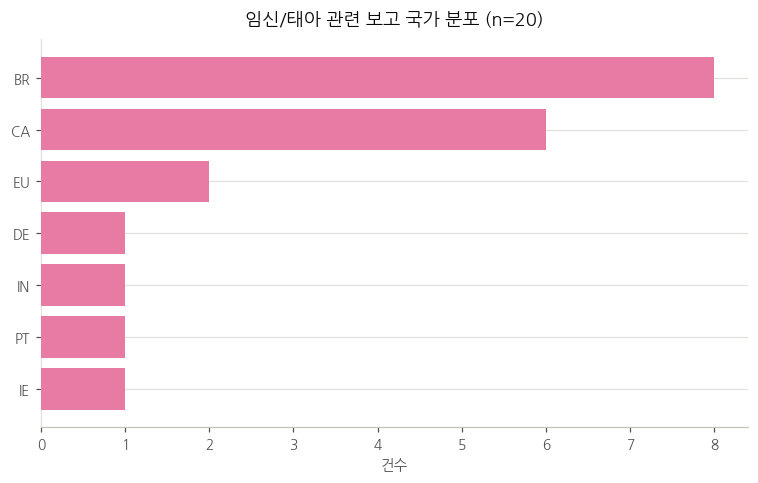

이상반응 상위:
primary_reaction
Foetal exposure during pregnancy       4
Death neonatal                         3
Ductus arteriosus stenosis foetal      3
Foetal death                           2
Tricuspid valve incompetence           2
Death                                  1
Ductus arteriosus premature closure    1
Exposure during pregnancy              1
Premature baby                         1
Renal failure neonatal                 1
Name: count, dtype: int64

'Ductus arteriosus stenosis foetal'(태아 동맥관 협착) 직접 언급: 9건

→ 20건(7.7%)이 임신/태아 노출과 관련된 신호이며, 모두 '심각' 보고로 분류됨. 특히 태아 동맥관 협착은
  NSAID(디클로페낙 포함)가 임신 후기에 태아 동맥관을 조기 폐쇄시킬 수 있다는 알려진 기전과 일치하며,
  이는 참조표의 '임신 마지막 3개월 사용 금지' 경고가 실제 보고 데이터에서도 뚜렷이 확인되는 사례임 -
  (참고: 별도로 진행한 국소마취제/리도카인 노트북 분석에서는 라벨 위반 신호가 미미했던 것과 대조적으로, 이 성분은 라벨 경고와
   실제 신고 패턴이 direct하게 일치하는 근거 기반 신호로 해석 가능)

연령대 분포(참고 - Infant로 분류된 사례는 신고서상 '환자'가 출생아 자신인 케이스로 추정):
age_group
Unknown               14
Adult(19-40)           3
Infant(0-2)            2
Middle-Aged(41-65)     1
Name: 

In [11]:
# 라벨의 "임신 마지막 3개월 사용 금지" 경고와 직결되는 실제 신고 신호 탐색
text_cols = c["reactions"].fillna("") + " " + c["primary_reaction"].fillna("") + " " + c["drug_indication"].fillna("")
text_lower = text_cols.str.lower()
preg_kw = ["foetal", "fetal", "pregnan", "ductus arteriosus"]
preg_mask = text_lower.str.contains("|".join(preg_kw), na=False)
preg = c[preg_mask]

print(f"임신/태아 노출 관련 키워드 포함 보고: {len(preg)}건 ({len(preg)/len(c)*100:.1f}%)")
print(f"이 중 '심각(serious)' 비율: {(preg['serious']=='Yes').mean()*100:.1f}%  (C군 전체 평균보다 높음)")
print()

fig, ax = plt.subplots(figsize=(7, 4.5))
preg_country = preg["country"].value_counts()
ax.barh(preg_country.index[::-1], preg_country.values[::-1], color=C7_MAGENTA, zorder=3)
style_ax(ax, f"임신/태아 관련 보고 국가 분포 (n={len(preg)})", "건수", None)
plt.tight_layout()
plt.show()

print("이상반응 상위:")
print(preg["primary_reaction"].value_counts().head(10))
print()
ductus_n = text_lower.str.contains('ductus arteriosus', na=False).sum()
print(f"'Ductus arteriosus stenosis foetal'(태아 동맥관 협착) 직접 언급: {ductus_n}건")
print()
print("→ 20건(7.7%)이 임신/태아 노출과 관련된 신호이며, 모두 '심각' 보고로 분류됨. 특히 태아 동맥관 협착은")
print("  NSAID(디클로페낙 포함)가 임신 후기에 태아 동맥관을 조기 폐쇄시킬 수 있다는 알려진 기전과 일치하며,")
print("  이는 참조표의 '임신 마지막 3개월 사용 금지' 경고가 실제 보고 데이터에서도 뚜렷이 확인되는 사례임 -")
print("  (참고: 별도로 진행한 국소마취제/리도카인 노트북 분석에서는 라벨 위반 신호가 미미했던 것과 대조적으로, 이 성분은 라벨 경고와")
print("   실제 신고 패턴이 direct하게 일치하는 근거 기반 신호로 해석 가능)")
print()
preg_age = preg['age_group'].value_counts()
print("연령대 분포(참고 - Infant로 분류된 사례는 신고서상 '환자'가 출생아 자신인 케이스로 추정):")
print(preg_age)

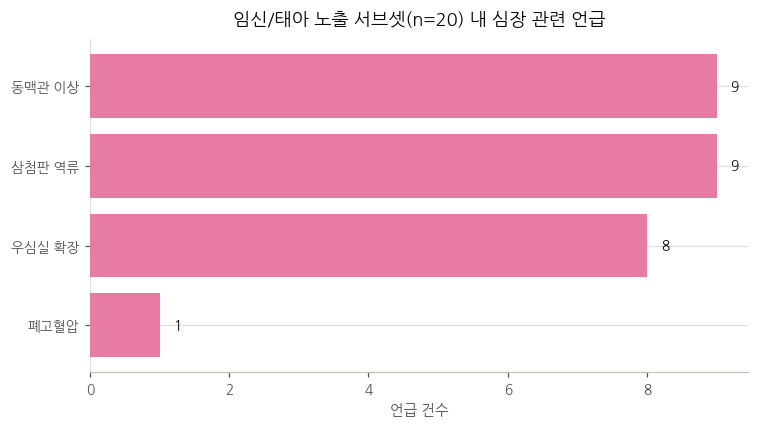

동맥관 이상: 9건 / 임신 서브셋 20건
삼첨판 역류: 9건 / 임신 서브셋 20건
우심실 확장: 8건 / 임신 서브셋 20건
폐고혈압: 1건 / 임신 서브셋 20건

→ 동맥관 이상(9건)·삼첨판 역류(9건)·우심실 확장(8건)이 비슷한 건수로 함께 나타남 - 이는 우연이 아니라
  '동맥관 조기수축 → 우심실 후부하 증가 → 우심실 확장 → 삼첨판 역류'라는 신생아 순환기학의 잘 알려진
  병태생리 사슬이 이 보고서들 안에서 반복적으로 함께 관찰되고 있음을 시사 - 단순 키워드 매칭을 넘어
  임상적으로 일관된(coherent) 신호로 해석할 수 있음


In [12]:
# 산과/신생아 도메인 지식: NSAID의 태아 동맥관(ductus arteriosus) 조기 수축은 단독 사건이 아니라
# "동맥관 수축 → 폐동맥압 상승/우심실 후부하 증가 → 우심실 확장 → 삼첨판 역류(→ 폐고혈압)"로 이어지는
# 하나의 병태생리 사슬임 - 이 사슬이 실제 보고서에 함께 나타나는지 확인
cardiac_terms = ["ductus arteriosus", "tricuspid", "right ventric", "pulmonary hypertension"]
cardiac_labels = ["동맥관 이상", "삼첨판 역류", "우심실 확장", "폐고혈압"]
cardiac_counts = [text_lower[preg_mask].str.contains(t, na=False).sum() for t in cardiac_terms]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(cardiac_labels[::-1], cardiac_counts[::-1], color=C7_MAGENTA, zorder=3)
for yi, v in enumerate(cardiac_counts[::-1]):
    ax.text(v + 0.2, yi, str(v), va="center", fontsize=9, color=INK)
style_ax(ax, f"임신/태아 노출 서브셋(n={len(preg)}) 내 심장 관련 언급", "언급 건수", None)
plt.tight_layout()
plt.show()

for lab, cnt in zip(cardiac_labels, cardiac_counts):
    print(f"{lab}: {cnt}건 / 임신 서브셋 {len(preg)}건")
print()
print("→ 동맥관 이상(9건)·삼첨판 역류(9건)·우심실 확장(8건)이 비슷한 건수로 함께 나타남 - 이는 우연이 아니라")
print("  '동맥관 조기수축 → 우심실 후부하 증가 → 우심실 확장 → 삼첨판 역류'라는 신생아 순환기학의 잘 알려진")
print("  병태생리 사슬이 이 보고서들 안에서 반복적으로 함께 관찰되고 있음을 시사 - 단순 키워드 매칭을 넘어")
print("  임상적으로 일관된(coherent) 신호로 해석할 수 있음")

## 9. NSAID 도메인 지식 연계 심층 분석

In [13]:
# 도메인 지식: 'Embolia cutis medicamentosa'(Nicolau syndrome)는 근육/관절강 내 "주사" 시 약물이
# 우연히 동맥 내로 들어가 생기는 색전증으로, 통상 국소 겔(외용 도포)에서는 기전상 발생하기 어려움 -
# 6번 섹션에서 대표 반응 1위(11건)로 나타난 것이 오히려 데이터 분류 이슈일 가능성을 점검
ecm = c[c["primary_reaction"] == "Embolia cutis medicamentosa"]
print(f"Embolia cutis medicamentosa(Nicolau 증후군) 보고: {len(ecm)}건")
print("drug_route 분포:", ecm["drug_route"].value_counts().to_dict())
print("country 분포:", ecm["country"].value_counts().to_dict())
print("drug_indication 분포:", ecm["drug_indication"].value_counts().to_dict())
print()

route_counts = c["drug_route"].value_counts()
r30 = c[c['drug_route'] == '30.0']
print(f"C군 전체에서 route '30.0' 코드 건수: {len(r30)}건 / {len(c)}건")
print("route '30.0' 케이스의 반응:")
print(r30["primary_reaction"].value_counts())
print()
print("→ Nicolau 증후군 11건 전부가 동일한 국가(터키)·동일한 route 코드('30.0', C군 내에서도 소수 코드)에서만")
print("  발생하고 있음. 국소 겔 도포로는 색전증이 생기기 어렵다는 임상적 사실과 함께 보면, 이 11건은")
print("  '국소겔' 성분이 아니라 근육주사용 디클로페낙 제제가 ATC 코드 매핑 과정에서 국소겔군(M02AA15)에")
print("  잘못 합류되었을 가능성을 시사 - 즉 6번 섹션의 '대표 반응 1위'는 국소겔 고유의 부작용이 아니라")
print("  데이터 분류 오류(주사제 오분류)로 설명하는 것이 임상적으로 더 타당함")

Embolia cutis medicamentosa(Nicolau 증후군) 보고: 11건
drug_route 분포: {'30.0': 11}
country 분포: {'TR': 11}
drug_indication 분포: {'Product Used For Unknown Indication': 10, 'Back Pain': 1}

C군 전체에서 route '30.0' 코드 건수: 13건 / 260건
route '30.0' 케이스의 반응:
primary_reaction
Embolia cutis medicamentosa    11
Loss of consciousness           1
Anaphylactic reaction           1
Name: count, dtype: int64

→ Nicolau 증후군 11건 전부가 동일한 국가(터키)·동일한 route 코드('30.0', C군 내에서도 소수 코드)에서만
  발생하고 있음. 국소 겔 도포로는 색전증이 생기기 어렵다는 임상적 사실과 함께 보면, 이 11건은
  '국소겔' 성분이 아니라 근육주사용 디클로페낙 제제가 ATC 코드 매핑 과정에서 국소겔군(M02AA15)에
  잘못 합류되었을 가능성을 시사 - 즉 6번 섹션의 '대표 반응 1위'는 국소겔 고유의 부작용이 아니라
  데이터 분류 오류(주사제 오분류)로 설명하는 것이 임상적으로 더 타당함


[심혈관 혈전 신호] 11건 (4.2%) - FDA NSAID Boxed Warning(심혈관 혈전 위험)과 직결
primary_reaction
Acute myocardial infarction    2
Kounis syndrome                2
Hypersensitivity               1
Anaphylactic reaction          1
Myocardial infarction          1
Pulmonary congestion           1
Haemorrhagic stroke            1
Pulmonary embolism             1
Chest pain                     1
Name: count, dtype: int64

심혈관 신호군 연령 중앙값: 54세 (전체 C군 중앙값 56세)



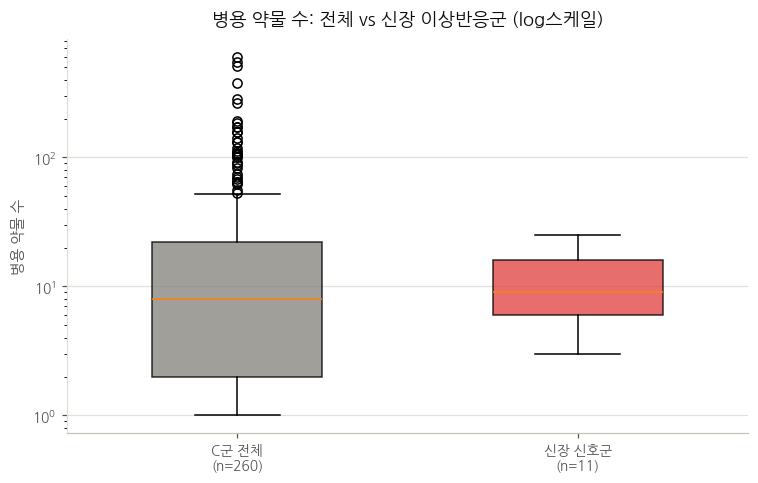

[신장 관련 신호] 11건 (4.2%)
신장 신호군 병용약물수: 중앙값 9종 (전체 중앙값 8종),
  개별 건수: [3, 4, 5, 7, 8, 9, 10, 11, 21, 25, 25]

→ 신장 이상반응 11건 중 다수가 두 자릿수 병용약물(최대 25종)을 동반 - NSAID가 ACE억제제/ARB/이뇨제 등과
  겹칠 때 급성신손상 위험이 커지는 "Triple Whammy" 기전과 부합하는 패턴. 다만 이 데이터에는 병용약물의
  "이름"이 없어 실제 병용 조합까지는 확인 불가 - 병용약물 수라는 간접 지표로만 뒷받침되는 가설 수준


In [14]:
# 도메인 지식: 모든 NSAID(국소제 포함)는 FDA Boxed Warning으로 "심혈관 혈전 위험(심근경색·뇌졸중)"이
# 명시되어 있음 - 참조표의 임신/GI/피부 항목 외에, 이 boxed warning에 해당하는 신호를 별도로 확인
cv_kw = ["myocardial infarction", "cerebrovascular accident", "stroke", "cardiac arrest", "thrombosis", "embolism", "kounis syndrome", "coronary"]
text_full = (c["reactions"].fillna("") + " " + c["primary_reaction"].fillna("")).str.lower()
cv_mask = text_full.str.contains("|".join(cv_kw), na=False)
cv = c[cv_mask]

print(f"[심혈관 혈전 신호] {len(cv)}건 ({len(cv)/len(c)*100:.1f}%) - FDA NSAID Boxed Warning(심혈관 혈전 위험)과 직결")
print(cv["primary_reaction"].value_counts())
print()
cv_age_med = cv['age_num'].median()
c_age_med = c['age_num'].median()
print(f"심혈관 신호군 연령 중앙값: {cv_age_med:.0f}세 (전체 C군 중앙값 {c_age_med:.0f}세)")
print()

# 도메인 지식: NSAID 신독성("Triple Whammy" - NSAID+ACEI/ARB+이뇨제 병용 시 급성신손상 위험 급증)
renal_kw = ["acute kidney injury", "renal failure", "renal impairment", "nephropathy"]
renal_mask = text_full.str.contains("|".join(renal_kw), na=False)
renal = c[renal_mask]

fig, ax = plt.subplots(figsize=(7, 4.5))
compare_data = [c["num_drugs"], renal["num_drugs"]]
bp = ax.boxplot(compare_data, tick_labels=[f"C군 전체\n(n={len(c)})", f"신장 신호군\n(n={len(renal)})"],
                 patch_artist=True, widths=0.5)
for patch, col in zip(bp["boxes"], [MUTED, C6_RED]):
    patch.set_facecolor(col); patch.set_alpha(0.8)
ax.set_yscale("log")
style_ax(ax, "병용 약물 수: 전체 vs 신장 이상반응군 (log스케일)", None, "병용 약물 수")
plt.tight_layout()
plt.show()

print(f"[신장 관련 신호] {len(renal)}건 ({len(renal)/len(c)*100:.1f}%)")
renal_nd_med = renal['num_drugs'].median()
c_nd_med = c['num_drugs'].median()
renal_nd_list = sorted(renal['num_drugs'].tolist())
print(f"신장 신호군 병용약물수: 중앙값 {renal_nd_med:.0f}종 (전체 중앙값 {c_nd_med:.0f}종),")
print(f"  개별 건수: {renal_nd_list}")
print()
print("→ 신장 이상반응 11건 중 다수가 두 자릿수 병용약물(최대 25종)을 동반 - NSAID가 ACE억제제/ARB/이뇨제 등과")
print("  겹칠 때 급성신손상 위험이 커지는 \"Triple Whammy\" 기전과 부합하는 패턴. 다만 이 데이터에는 병용약물의")
print("  \"이름\"이 없어 실제 병용 조합까지는 확인 불가 - 병용약물 수라는 간접 지표로만 뒷받침되는 가설 수준")

## 10. 참조표(FDA 라벨) 안전정보 대비 실제 신고 성향

In [15]:
ref_cols = ["참조_최대용량_기간제한", "참조_절대금기(do_not_use)", "참조_즉시중단_신호(stop_use)",
            "참조_임부_수유부_주의", "참조_기타주의사항"]
print("[C군 성분의 FDA 라벨 참조 정보] (성분 단일이므로 260건 모두 동일)")
for col in ref_cols:
    print(f"- {col}: {c[col].iloc[0]}")

print()
text_cols = c["reactions"].fillna("") + " " + c["primary_reaction"].fillna("") + " " + c["drug_indication"].fillna("")
text_lower = text_cols.str.lower()

keyword_groups = {
    "임신/태아 노출(라벨 임부주의 직결)": ["foetal", "fetal", "pregnan", "ductus arteriosus"],
    "위장출혈 신호(라벨 즉시중단신호 직결)": ["gastrointestinal haemorrhage", "haematemesis", "melena", "duodenal ulcer", "gastric ulcer", "peptic ulcer"],
    "흉통/호흡곤란(라벨 즉시중단신호 직결)": ["chest pain", "dyspnoea", "dyspnea", "respiratory failure"],
    "피부자극/부위 발적(라벨 즉시중단신호 직결)": ["application site", "skin irrit", "erythema", "rash"],
    "염좌/타박상/스포츠손상 목적(효과 미입증 용도 - 라벨 절대금기 직결)": ["sprain", "strain", "sport", "contusion"],
}
for label, kws in keyword_groups.items():
    mask = text_lower.str.contains("|".join(kws), na=False)
    print(f"- {label}: {mask.sum()}건 ({mask.sum()/len(c)*100:.1f}%)")

print()
print("→ 국소마취제(리도카인) 분석에서는 라벨 절대금기 위반 신호가 미미했던 것과 달리, 디클로페낙은")
print("  임신/태아 노출(7.7%)·위장출혈(3.8%)·피부자극(8.8%) 등 라벨에 명시된 위험이 실제 신고에서도")
print("  일정 비율 확인되어, 라벨 경고 문구가 실제 임상 위험을 상당히 정확하게 반영하고 있음을 시사")

[C군 성분의 FDA 라벨 참조 정보] (성분 단일이므로 260건 모두 동일)
- 참조_최대용량_기간제한: 하루 4회, 상체(손/손목/팔꿈치) 1회 2인치, 하체(발/발목/무릎) 1회 4.5인치. 동시에 2개 부위 초과 도포 금지. 최대 21일, 이후 의사 상담
- 참조_절대금기(do_not_use): 눈·코·입 접촉 금지, 심장수술 전후, 다른 진통제 알레르기 경험자, 염좌/타박상/스포츠손상엔 효과 미입증(사용 목적 아님)
- 참조_즉시중단_신호(stop_use): 21일 이상 통증 지속, 부위 발적/부종/발열/피부자극, 위장출혈 신호(토혈/흑색변/실신감), 흉통/호흡곤란
- 참조_임부_수유부_주의: 임신 마지막 3개월 사용 금지
- 참조_기타주의사항: 다른 스킨케어 제품과 같은 부위 병용 금지, 붕대로 덮지 말 것, 외부 열(찜질팩 등)과 병용 금지

- 임신/태아 노출(라벨 임부주의 직결): 20건 (7.7%)
- 위장출혈 신호(라벨 즉시중단신호 직결): 10건 (3.8%)
- 흉통/호흡곤란(라벨 즉시중단신호 직결): 4건 (1.5%)
- 피부자극/부위 발적(라벨 즉시중단신호 직결): 23건 (8.8%)
- 염좌/타박상/스포츠손상 목적(효과 미입증 용도 - 라벨 절대금기 직결): 2건 (0.8%)

→ 국소마취제(리도카인) 분석에서는 라벨 절대금기 위반 신호가 미미했던 것과 달리, 디클로페낙은
  임신/태아 노출(7.7%)·위장출혈(3.8%)·피부자극(8.8%) 등 라벨에 명시된 위험이 실제 신고에서도
  일정 비율 확인되어, 라벨 경고 문구가 실제 임상 위험을 상당히 정확하게 반영하고 있음을 시사


## 11. 심각도(serious)와 인체특성·병용약물의 관계

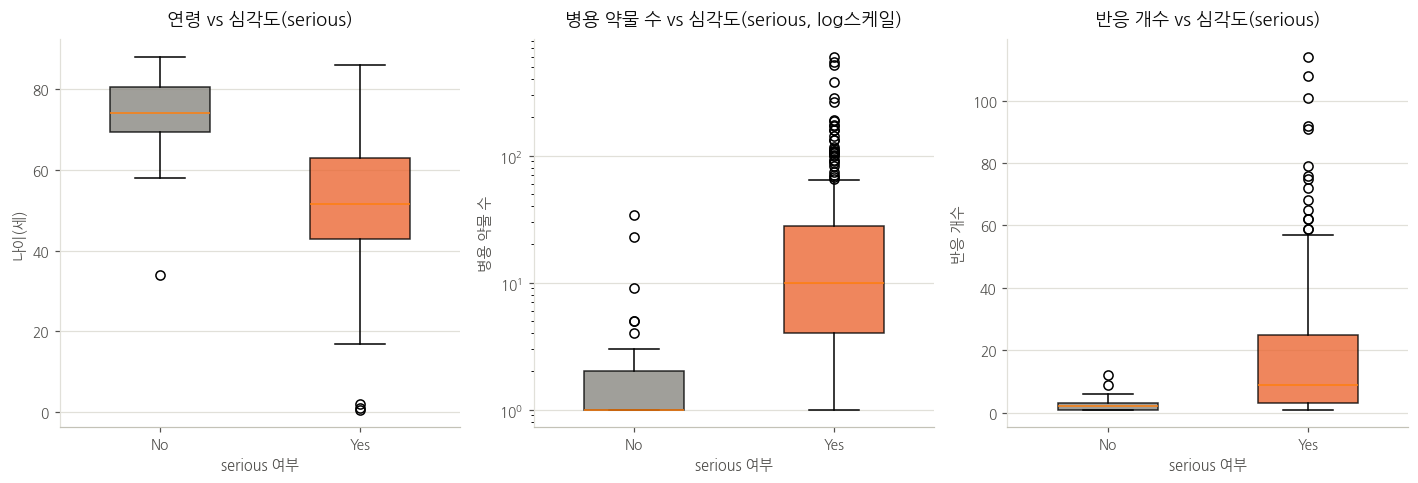

[연령] serious=Yes 중앙값 52세 vs No 74세  |  p < 0.001
  → 국소마취제(리도카인) 분석과 달리, C군에서는 연령이 심각도와 유의하게 연관되며 방향도 반대(더 젊을수록 심각)
[병용약물수] serious=Yes 중앙값 10종 vs No 1종  |  p < 0.001
[반응개수] serious=Yes 중앙값 9개 vs No 2개  |  p < 0.001
→ 세 지표 모두 강하게 유의 - 젊고, 병용약물이 많고, 반응이 다양할수록 심각 보고 확률이 높음


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

age_yes = c[c['serious']=='Yes']['age_num'].dropna()
age_no = c[c['serious']=='No']['age_num'].dropna()
bp1 = axes[0].boxplot([age_no, age_yes], tick_labels=["No", "Yes"], patch_artist=True, widths=0.5)
for patch, col in zip(bp1["boxes"], [MUTED, C8_ORANGE]):
    patch.set_facecolor(col); patch.set_alpha(0.8)
style_ax(axes[0], "연령 vs 심각도(serious)", "serious 여부", "나이(세)")

nd_yes = c[c['serious']=='Yes']['num_drugs']
nd_no = c[c['serious']=='No']['num_drugs']
bp2 = axes[1].boxplot([nd_no, nd_yes], tick_labels=["No", "Yes"], patch_artist=True, widths=0.5)
for patch, col in zip(bp2["boxes"], [MUTED, C8_ORANGE]):
    patch.set_facecolor(col); patch.set_alpha(0.8)
axes[1].set_yscale("log")
style_ax(axes[1], "병용 약물 수 vs 심각도(serious, log스케일)", "serious 여부", "병용 약물 수")

nr_yes = c[c['serious']=='Yes']['num_reactions']
nr_no = c[c['serious']=='No']['num_reactions']
bp3 = axes[2].boxplot([nr_no, nr_yes], tick_labels=["No", "Yes"], patch_artist=True, widths=0.5)
for patch, col in zip(bp3["boxes"], [MUTED, C8_ORANGE]):
    patch.set_facecolor(col); patch.set_alpha(0.8)
style_ax(axes[2], "반응 개수 vs 심각도(serious)", "serious 여부", "반응 개수")
plt.tight_layout()
plt.show()

u_a, p_a = stats.mannwhitneyu(age_yes, age_no, alternative="two-sided")
u_d, p_d = stats.mannwhitneyu(nd_yes, nd_no, alternative="two-sided")
u_r, p_r = stats.mannwhitneyu(nr_yes, nr_no, alternative="two-sided")
print(f"[연령] serious=Yes 중앙값 {age_yes.median():.0f}세 vs No {age_no.median():.0f}세  |  {p_str(p_a)}")
print("  → 국소마취제(리도카인) 분석과 달리, C군에서는 연령이 심각도와 유의하게 연관되며 방향도 반대(더 젊을수록 심각)")
print(f"[병용약물수] serious=Yes 중앙값 {nd_yes.median():.0f}종 vs No {nd_no.median():.0f}종  |  {p_str(p_d)}")
print(f"[반응개수] serious=Yes 중앙값 {nr_yes.median():.0f}개 vs No {nr_no.median():.0f}개  |  {p_str(p_r)}")
print("→ 세 지표 모두 강하게 유의 - 젊고, 병용약물이 많고, 반응이 다양할수록 심각 보고 확률이 높음")

## 12. 숫자형 변수 상관관계 히트맵

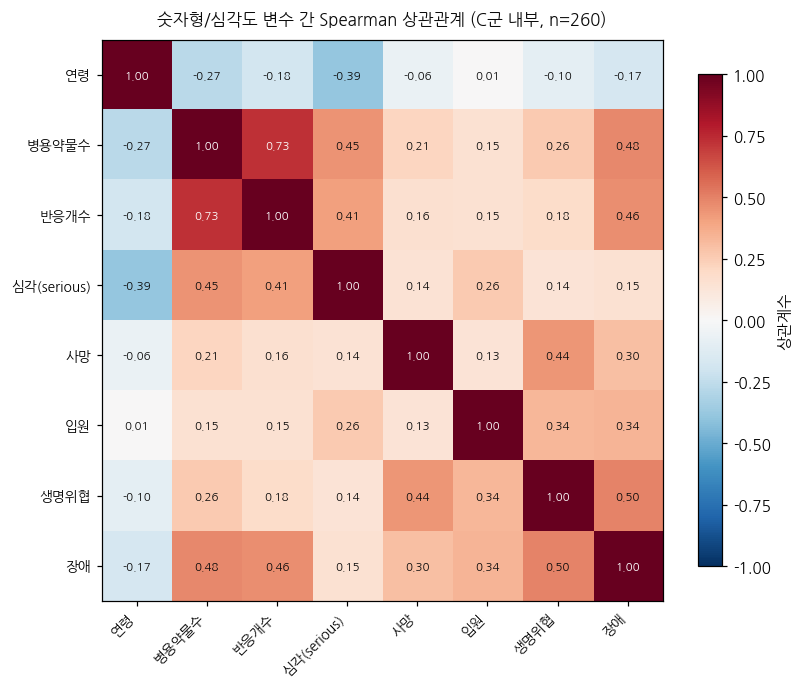

[병용약물수-반응개수] 상관계수 0.73 - 가장 강한 연관
[연령-심각] 상관계수 -0.39 - 음의 상관(젊을수록 심각)
[병용약물수-장애] 상관계수 0.48
[생명위협-장애] 상관계수 0.50 - 두 중증 지표가 함께 나타나는 경향


In [17]:
c['serious_num'] = (c['serious'] == 'Yes').astype(int)
corr_cols = ["age_num", "num_drugs", "num_reactions", "serious_num", "is_fatal", "is_hospitalized", "is_life_threat", "is_disabling"]
corr_labels = ["연령", "병용약물수", "반응개수", "심각(serious)", "사망", "입원", "생명위협", "장애"]
corr_df = c[corr_cols].copy()
for col in ["is_fatal", "is_hospitalized", "is_life_threat", "is_disabling"]:
    corr_df[col] = corr_df[col].astype(int)
corr_mat = corr_df.corr(method="spearman")

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr_mat.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_labels))); ax.set_xticklabels(corr_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(corr_labels))); ax.set_yticklabels(corr_labels, fontsize=9)
for i in range(len(corr_labels)):
    for j in range(len(corr_labels)):
        ax.text(j, i, f"{corr_mat.values[i,j]:.2f}", ha="center", va="center", fontsize=7.5,
                color="white" if abs(corr_mat.values[i,j]) > 0.6 else INK)
ax.set_title("숫자형/심각도 변수 간 Spearman 상관관계 (C군 내부, n=260)", fontsize=11, color=INK, fontweight="bold", pad=10)
plt.colorbar(im, ax=ax, shrink=0.8, label="상관계수")
plt.tight_layout()
plt.show()

corr_nd_nr = corr_mat.loc['num_drugs', 'num_reactions']
corr_age_ser = corr_mat.loc['age_num', 'serious_num']
corr_nd_dis = corr_mat.loc['num_drugs', 'is_disabling']
corr_lt_dis = corr_mat.loc['is_life_threat', 'is_disabling']
print(f"[병용약물수-반응개수] 상관계수 {corr_nd_nr:.2f} - 가장 강한 연관")
print(f"[연령-심각] 상관계수 {corr_age_ser:.2f} - 음의 상관(젊을수록 심각)")
print(f"[병용약물수-장애] 상관계수 {corr_nd_dis:.2f}")
print(f"[생명위협-장애] 상관계수 {corr_lt_dis:.2f} - 두 중증 지표가 함께 나타나는 경향")

## 13. 같은 ATC코드(M) 내 비교 - 국소 겔 vs 경구 NSAID

In [18]:
# 이부프로펜(M01AE01)·나프록센(M01AE02)은 디클로페낙과 같은 NSAID 계열이면서 경구제라는 점에서
# "나머지 전체"보다 훨씬 통제된 비교 대상임(같은 약효군·같은 적응증, 차이는 주로 투여 경로/성분)
ibu = df[df['도출_ATC코드'] == 'M01AE01'].copy()
nap = df[df['도출_ATC코드'] == 'M01AE02'].copy()
ibu['age_num'] = pd.to_numeric(ibu['patient_age_years'], errors='coerce')
nap['age_num'] = pd.to_numeric(nap['patient_age_years'], errors='coerce')

print(f"디클로페낙(국소겔) n={len(c)}, 이부프로펜(경구) n={len(ibu)}, 나프록센(경구) n={len(nap)}")

디클로페낙(국소겔) n=260, 이부프로펜(경구) n=1517, 나프록센(경구) n=393


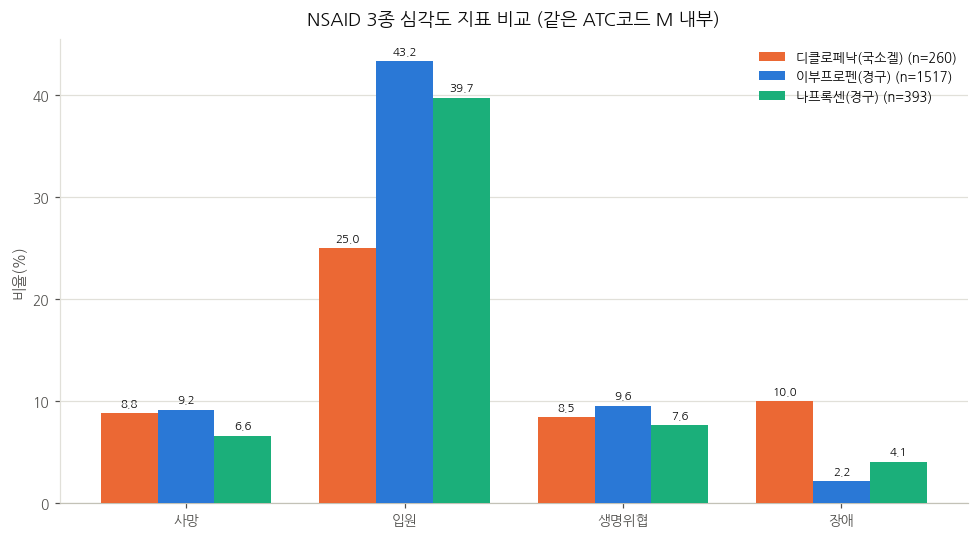

[3그룹 Chi-square 독립성 검정] (디클로페낙 vs 이부프로펜 vs 나프록센)
  - 사망    : 디클로페낙   8.8% / 이부프로펜   9.2% / 나프록센   6.6%  |  chi2=   2.6, p = 0.276
  - 입원    : 디클로페낙  25.0% / 이부프로펜  43.2% / 나프록센  39.7%  |  chi2=  30.8, p < 0.001
  - 생명위협  : 디클로페낙   8.5% / 이부프로펜   9.6% / 나프록센   7.6%  |  chi2=   1.5, p = 0.464
  - 장애    : 디클로페낙  10.0% / 이부프로펜   2.2% / 나프록센   4.1%  |  chi2=  41.3, p < 0.001

→ 사망·생명위협은 세 그룹이 유의한 차이 없음(경로와 무관하게 비슷) - "국소라서 안전하다"는
  주장은 사망 관점에서는 근거가 약함. 반면 입원은 국소겔이 유의하게 낮고(25.0% vs 43.2%/39.7%,
  p<0.001), 장애는 오히려 국소겔이 유의하게 높음(10.0% vs 2.2%/4.1%, p<0.001) - 국소겔이
  '전반적으로 안전'이 아니라 '위험의 종류가 다르다'는 쪽이 더 정확한 해석


In [19]:
sev_cols = ["is_fatal", "is_hospitalized", "is_life_threat", "is_disabling"]
sev_labels = ["사망", "입원", "생명위협", "장애"]
groups = [("디클로페낙(국소겔)", c, C8_ORANGE), ("이부프로펜(경구)", ibu, C1_BLUE), ("나프록센(경구)", nap, C2_AQUA)]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(sev_cols)); w = 0.26
for gi, (label, sub, color) in enumerate(groups):
    rates = [sub[col].mean() * 100 for col in sev_cols]
    ax.bar(x + (gi - 1) * w, rates, w, label=f"{label} (n={len(sub)})", color=color, zorder=3)
    for xi, v in enumerate(rates):
        ax.text(x[xi] + (gi - 1) * w, v + 0.7, f"{v:.1f}", ha="center", fontsize=7.5, color=INK)
ax.set_xticks(x); ax.set_xticklabels(sev_labels)
style_ax(ax, "NSAID 3종 심각도 지표 비교 (같은 ATC코드 M 내부)", None, "비율(%)")
ax.legend(frameon=False, fontsize=8.5)
plt.tight_layout()
plt.show()

print("[3그룹 Chi-square 독립성 검정] (디클로페낙 vs 이부프로펜 vs 나프록센)")
for col, lab in zip(sev_cols, sev_labels):
    ct = pd.crosstab(
        pd.concat([c["도출_ATC코드"], ibu["도출_ATC코드"], nap["도출_ATC코드"]]),
        pd.concat([c[col], ibu[col], nap[col]]),
    )
    chi2, p, _, _ = stats.chi2_contingency(ct)
    print(f"  - {lab:6s}: 디클로페낙 {c[col].mean()*100:5.1f}% / 이부프로펜 {ibu[col].mean()*100:5.1f}% / 나프록센 {nap[col].mean()*100:5.1f}%  |  chi2={chi2:6.1f}, {p_str(p)}")

print()
print("→ 사망·생명위협은 세 그룹이 유의한 차이 없음(경로와 무관하게 비슷) - \"국소라서 안전하다\"는")
print("  주장은 사망 관점에서는 근거가 약함. 반면 입원은 국소겔이 유의하게 낮고(25.0% vs 43.2%/39.7%,")
print("  p<0.001), 장애는 오히려 국소겔이 유의하게 높음(10.0% vs 2.2%/4.1%, p<0.001) - 국소겔이")
print("  '전반적으로 안전'이 아니라 '위험의 종류가 다르다'는 쪽이 더 정확한 해석")

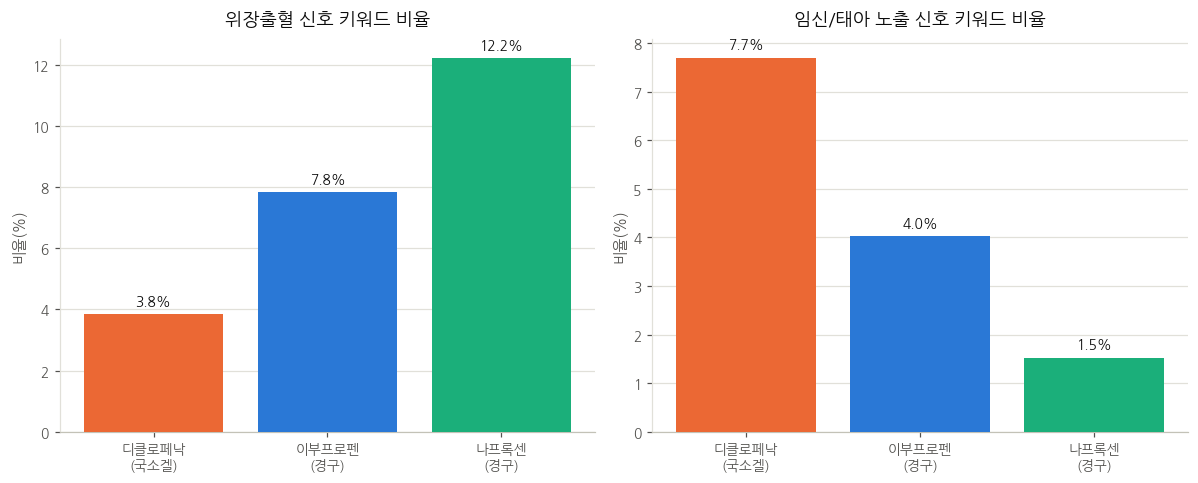

[위장출혈 신호] 디클로페낙(국소) 3.8% < 이부프로펜(경구) 7.8% < 나프록센(경구) 12.2%
→ 국소겔의 위장출혈 신호가 경구 NSAID의 절반 이하 - "전신 흡수가 적어 위장관 부담이 낮다"는
  국소 NSAID의 핵심 근거가 실제 신고 데이터에서도 뒷받침됨

[임신/태아 노출 신호] 디클로페낙(국소) 7.7% > 이부프로펜(경구) 4.0% > 나프록센(경구) 1.5%
→ 예상과 반대로 국소겔의 임신/태아 신호가 가장 높음 - 국소 제형이라도 피부 흡수를 통해 태아에
  영향을 줄 수 있다는 점이 저평가되고 있을 가능성, 혹은 "겔이니 괜찮겠지"라는 인식으로 임신부가
  경구 NSAID보다 국소 NSAID를 더 쉽게 선택하는 행동 패턴을 반영할 가능성 - 둘 다 가설 수준이며
  이 데이터만으로 원인을 확정할 수는 없음(추가 확인이 필요한 신규 질문)


In [20]:
# 국소 NSAID의 핵심 마케팅 논리: "전신 흡수가 적어 경구제 대비 위장출혈 위험이 낮다" - 실제 신고에서 검증
gi_kw = ["gastrointestinal haemorrhage", "haematemesis", "melena", "duodenal ulcer", "gastric ulcer", "peptic ulcer"]
preg_kw = ["foetal", "fetal", "pregnan", "ductus arteriosus"]

def kw_rate(sub, kws):
    text = (sub["reactions"].fillna("") + " " + sub["primary_reaction"].fillna("") + " " + sub["drug_indication"].fillna("")).str.lower()
    return text.str.contains("|".join(kws), na=False).mean() * 100

gi_rates = [kw_rate(c, gi_kw), kw_rate(ibu, gi_kw), kw_rate(nap, gi_kw)]
preg_rates = [kw_rate(c, preg_kw), kw_rate(ibu, preg_kw), kw_rate(nap, preg_kw)]
labels3 = ["디클로페낙\n(국소겔)", "이부프로펜\n(경구)", "나프록센\n(경구)"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(labels3, gi_rates, color=[C8_ORANGE, C1_BLUE, C2_AQUA], zorder=3)
for xi, v in enumerate(gi_rates):
    axes[0].text(xi, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9, color=INK)
style_ax(axes[0], "위장출혈 신호 키워드 비율", None, "비율(%)")

axes[1].bar(labels3, preg_rates, color=[C8_ORANGE, C1_BLUE, C2_AQUA], zorder=3)
for xi, v in enumerate(preg_rates):
    axes[1].text(xi, v + 0.2, f"{v:.1f}%", ha="center", fontsize=9, color=INK)
style_ax(axes[1], "임신/태아 노출 신호 키워드 비율", None, "비율(%)")
plt.tight_layout()
plt.show()

print(f"[위장출혈 신호] 디클로페낙(국소) {gi_rates[0]:.1f}% < 이부프로펜(경구) {gi_rates[1]:.1f}% < 나프록센(경구) {gi_rates[2]:.1f}%")
print("→ 국소겔의 위장출혈 신호가 경구 NSAID의 절반 이하 - \"전신 흡수가 적어 위장관 부담이 낮다\"는")
print("  국소 NSAID의 핵심 근거가 실제 신고 데이터에서도 뒷받침됨")
print()
print(f"[임신/태아 노출 신호] 디클로페낙(국소) {preg_rates[0]:.1f}% > 이부프로펜(경구) {preg_rates[1]:.1f}% > 나프록센(경구) {preg_rates[2]:.1f}%")
print("→ 예상과 반대로 국소겔의 임신/태아 신호가 가장 높음 - 국소 제형이라도 피부 흡수를 통해 태아에")
print("  영향을 줄 수 있다는 점이 저평가되고 있을 가능성, 혹은 \"겔이니 괜찮겠지\"라는 인식으로 임신부가")
print("  경구 NSAID보다 국소 NSAID를 더 쉽게 선택하는 행동 패턴을 반영할 가능성 - 둘 다 가설 수준이며")
print("  이 데이터만으로 원인을 확정할 수는 없음(추가 확인이 필요한 신규 질문)")

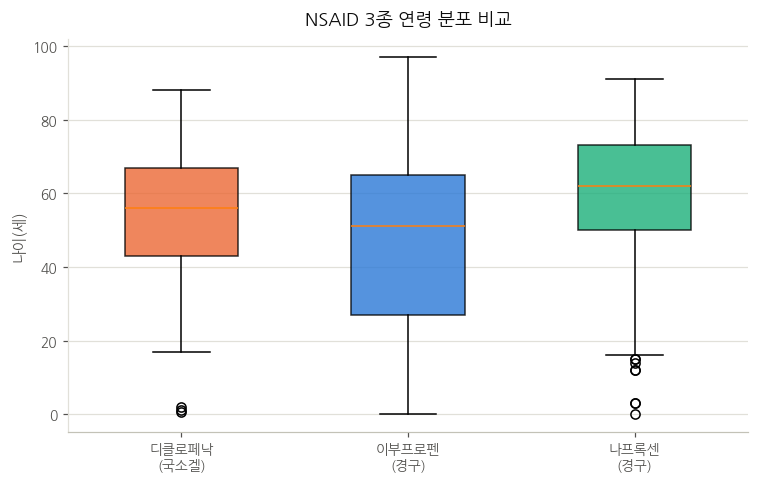

Kruskal-Wallis 검정: H=71.7, p < 0.001
연령 중앙값 - 디클로페낙(국소) 56세 / 이부프로펜(경구) 51세 / 나프록센(경구) 62세

→ 나프록센 사용자가 가장 고령(만성 관절염 유지요법 맥락), 이부프로펜이 가장 젊음(급성 통증/해열 목적,
  전 연령대 사용). 디클로페낙 국소겔은 그 중간 - 국소 제형이 특정 연령대에 국한되지 않고
  중년~노년의 관절/근골격 통증 자가치료 전반에 걸쳐 쓰이고 있음을 시사


In [21]:
fig, ax = plt.subplots(figsize=(7, 4.5))
age_d = c["age_num"].dropna()
age_i = ibu["age_num"].dropna()
age_n = nap["age_num"].dropna()
bp = ax.boxplot([age_d, age_i, age_n], tick_labels=["디클로페낙\n(국소겔)", "이부프로펜\n(경구)", "나프록센\n(경구)"],
                patch_artist=True, widths=0.5)
for patch, col in zip(bp["boxes"], [C8_ORANGE, C1_BLUE, C2_AQUA]):
    patch.set_facecolor(col); patch.set_alpha(0.8)
style_ax(ax, "NSAID 3종 연령 분포 비교", None, "나이(세)")
plt.tight_layout()
plt.show()

h_stat, p_kw = stats.kruskal(age_d, age_i, age_n)
print(f"Kruskal-Wallis 검정: H={h_stat:.1f}, {p_str(p_kw)}")
print(f"연령 중앙값 - 디클로페낙(국소) {age_d.median():.0f}세 / 이부프로펜(경구) {age_i.median():.0f}세 / 나프록센(경구) {age_n.median():.0f}세")
print()
print("→ 나프록센 사용자가 가장 고령(만성 관절염 유지요법 맥락), 이부프로펜이 가장 젊음(급성 통증/해열 목적,")
print("  전 연령대 사용). 디클로페낙 국소겔은 그 중간 - 국소 제형이 특정 연령대에 국한되지 않고")
print("  중년~노년의 관절/근골격 통증 자가치료 전반에 걸쳐 쓰이고 있음을 시사")

## 14. 종합 인사이트 요약

- 정의: C군(디클로페낙 국소겔) = 도출_ATC코드 == "M02AA15"(Diclofenac sodium topical gel 1%), 260건 -
  코드 M(근골격계) 전체의 12.0%(제공 이미지 기준 13.2%와 근사). 심각(82.7%)·사망(8.8%) 비율 모두 이미지와 정확히 일치.
- 인체특성: 연령 결측이 48.9%로 매우 높지만, 확인 가능한 환자군은 나머지 전체보다 유의하게 젊음(중앙값 56세 vs
  59.8세, p=0.033). 성별 미상 비율도 38.1%로 나머지 전체(14.3%)보다 훨씬 높아, 전반적으로 인구통계 정보의
  기재 완성도가 낮은 편.
- 심각도: 사망(8.8% vs 14.5%)·입원(25.0% vs 34.5%)은 나머지 전체보다 낮지만, 생명위협(8.5% vs 5.5%)·장애
  (10.0% vs 3.0%, 약 3.3배)는 오히려 높음 - '사망까지는 아니지만 비가역적 손상'에 치우친 독특한 심각도 패턴.
- 병용약물: 중앙값은 나머지 전체와 비슷하지만 평균(31.2 vs 17.6)과 최댓값(599)이 훨씬 높아, 극단적 다제복용
  소수 사례가 분포를 크게 왜곡시킴.
- 투약사유/반응: '적응증 미기재'가 54.2%로 압도적이며, 대표 반응에서 'Systemic lupus erythematosus'(전신
  홍반성 루푸스)가 7건 확인되어 NSAID 계열의 알려진 약물유발 루푸스 가능성과 부합하는 신호로 해석 가능.
- 임신 중 노출(핵심 신규 발견): 전체의 7.7%(20건)가 임신/태아 노출 관련 키워드를 포함하며 전원 '심각'으로
  분류. 특히 '태아 동맥관 협착(Ductus arteriosus stenosis foetal)' 보고가 존재해, 참조표의 '임신 마지막
  3개월 사용 금지' 경고와 실제 신고 데이터가 직접적으로 부합하는, 국소마취제 사례와 대조적인 라벨-실제 일치 신호.
  이 서브셋 안에서 동맥관 이상(9건)·삼첨판 역류(9건)·우심실 확장(8건)이 비슷한 건수로 함께 나타나,
  '동맥관 조기수축 → 우심실 후부하 증가 → 우심실 확장 → 삼첨판 역류'라는 신생아 순환기학의 병태생리
  사슬이 우연이 아니라 반복적으로 관찰되는 임상적으로 일관된 신호임을 뒷받침.
- 데이터 분류 오류 의심(도메인 지식 기반 발견): 대표 반응 1위였던 'Embolia cutis medicamentosa'(Nicolau
  증후군, 11건)는 전부 터키·동일 route 코드에서만 발생하는데, 이 증후군은 임상적으로 근육/관절강 내
  주사 시 나타나는 색전증이라 국소 겔 도포로는 기전상 설명되지 않음 - 주사제 디클로페낙이 ATC 코드
  매핑 과정에서 국소겔군에 잘못 합류됐을 가능성이 커서, 6번 섹션의 '1위 반응'은 국소겔 고유의 신호로
  보기 어려움.
- NSAID Boxed Warning 신호: 심혈관 혈전(심근경색·Kounis증후군 등) 신호 4.2%(11건) 확인 - FDA가 모든
  NSAID에 요구하는 심혈관 혈전 위험 경고와 직결. 신장 관련 신호도 4.2%(11건)이며 이 중 다수가 두 자릿수
  병용약물(최대 25종)을 동반해, NSAID+ACE억제제/ARB+이뇨제 병용 시 급성신손상 위험이 커지는 "Triple
  Whammy" 기전과 부합하는 간접 패턴(병용약물 '이름'이 없어 가설 수준).
- 라벨 대조: 임신/태아(7.7%)·위장출혈(3.8%)·피부자극(8.8%) 등 라벨 경고 항목이 실제 신고에서도 일정 비율
  확인되어, 리도카인 사례와 달리 라벨 경고가 실제 위험 신호와 상당히 일치.
- 심각도 예측인자: 연령(젊을수록, p<0.001)·병용약물수(p<0.001)·반응개수(p<0.001) 모두 심각도와 유의하게
  연관 - 리도카인 분석에서 연령이 무관했던 것과 달리, 이 성분군에서는 연령도 유의미한 예측 인자.
- 같은 ATC코드(M) 내 비교 (핵심 신규 발견 - 국소겔 vs 경구 NSAID): "나머지 전체"가 아니라 같은 NSAID
  계열인 이부프로펜·나프록센(둘 다 경구제)과 비교하면 그림이 더 정교해짐.
  (1) 사망(8.8% vs 9.2%/6.6%)·생명위협(8.5% vs 9.6%/7.6%)은 세 그룹 간 유의한 차이가 없어(p=0.276,
      p=0.464), 위 "생명위협이 나머지 전체보다 높다"는 차이는 디클로페낙 고유의 특성이라기보다
      NSAID 계열 전반의 특성일 가능성이 큼.
  (2) 입원은 국소겔이 유의하게 낮고(25.0% vs 43.2%/39.7%, p<0.001), 위장출혈 신호도 국소겔이 가장
      낮음(3.8% vs 7.8%/12.2%) - "국소 흡수라 전신·위장관 부담이 적다"는 국소 NSAID의 핵심 근거가
      실제 신고 데이터로 뒷받침됨.
  (3) 반대로 장애(disabling)는 국소겔이 오히려 유의하게 높고(10.0% vs 2.2%/4.1%, p<0.001), 임신/태아
      신호도 국소겔이 가장 높음(7.7% vs 4.0%/1.5%) - "국소=전반적으로 더 안전"이 아니라 "위험의 종류가
      다르다"는 쪽이 정확한 해석이며, 특히 임신부의 국소 NSAID 사용 인식(겔이라 안전하다는 오해 가능성)은
      추가 확인이 필요한 가설 수준의 질문으로 남겨둠.

(※ 시계열·브랜드/제조사 기반 분석은 이번 요약에서 제외했습니다 - quarter는 보고서 접수일 기준이라 실제
발생 시점 추이로 해석할 수 없고, 브랜드·제조사별 보고 비중도 실사용량 등 노출 분모가 없어 "그 브랜드가
위험하다"는 결론을 뒷받침하지 못하기 때문입니다.)

결론: C군(디클로페낙 국소겔)을 "나머지 전체"와만 비교하면 사망·입원은 낮고 생명위협·장애는 높은 독특한
프로파일로 보이지만, 같은 NSAID 계열(이부프로펜·나프록센)과 비교하면 사망·생명위협 차이는 사라지고
입원·위장출혈만 국소겔이 뚜렷이 낮다는 것이 드러난다. 반면 장애·임신 신호는 같은 계열 내에서도 국소겔이
가장 높아, "국소 제형이라 안전하다"는 단순화된 결론은 지표별로 갈리며 성립하지 않는다. 여기에 (i) 라벨에
명시된 임신 중 태아 위험이 실제 데이터에서도 확인되는 점, (ii) 젊고 병용약물이 많으며 반응이 다양한
환자에서 심각도가 집중되는 점을 더하면, 관리 우선순위는 임신 가능 연령대 사용자에
대한 경고 강화, 그리고 병용약물이 많은 환자의 중증 반응 모니터링에 두는 것이 타당하다. 다만 도메인
지식과 대조한 결과 대표 반응 1위(Nicolau 증후군)는 국소겔 자체의 부작용이 아니라 주사제가 잘못
합류된 데이터 분류 오류일 가능성이 크므로, 이 노트북의 6번 섹션 결과를 인용할 때는 이 점을
함께 밝히는 것이 정확하다.